# Лекция: Компьютерное зрение. 
## GAN & VAE. Часть 1.
**Преподаватель**: Шевченко Елена, Т-Банк

**Аудитория**: ФКН ВШЭ, МФТИ

### Содержание
1. VAE: FOUNDATIONS
    - Autoencoder recap
    - Постановка задачи VAE
    - ELBO
    - Reparametrization trick
    - CVAE
2. VAE: DISCRETIZATION (VQ-VAE)
   - Проблематика
   - Постановка
   - Применение
3. GAN BASICS
    - GAN
    - DCGAN
    - WGAN
    - VAE vs GAN
4. GAN: SCALING UP (BigGAN, StyleGAN, CycleGAN)
   - BigGAN
   - StyleGAN
   - CycleGAN
5. HYBRID MODELS (VAE + GAN)

# 1. VAE: FOUNDATIONS

## 1.1 Autoencoder (Recap)
![autoencoder](assets/autoencoder_model.png)
### Суть
- учимся сжимать данные и разжимать без потерь
- self-supervised
- Архитектура:
  - Encoder сжимает до `latent space` (bottleneck) $$ z = f_\theta(x) $$
  - Decoder расжимает обратно в картинку
    $$ \hat{x} = g_\phi(z) $$
  - latent space не контролируется (скрытое представление может быть из любого распределения)
    - $ z \in \mathbb{R}^k $
    - $ k \ll d$ (размер bottleneck меньше входа)
  - Loss: $$ L = \mathcal{L}(x, \hat{x}) $$
![ae](assets/ae.png)
### Проблематика
**Идеальная модель автоэнкодера находит баланс между**
  - Достаточной чувствительностью к входным данным для их точного восстановления.
  - Достаточной нечувствительностью, чтобы избежать простого запоминания или переобучения на тренировочных данных.

**Проблемы**
  - Можем просто запомнить обучающие данные
  - Сжатые признаки могут быть нерепрезентативны
  - Плохо работает с очень сложными данными
  - Трудно выбрать архитектуру (подбор размера bottleneck + регуляризации)
### Регуляризация
**Важность регуляризации**
  - учить структуру данных
  - выделять важные признаки
  - не переобучаться
  - делать представления более полезными

**Виды регуляриации**
- Размеры Bottleneck
- L1 / L2 регуляризация весов
  - L2 - регуляризация весов: $ L = L_{reconstruction} + \lambda \sum_{i} w_i^2 $
  - L1 - регуляризация весов: $ L = L_{reconstruction} + \lambda \sum_{i} |w_i| $ - реже
  - L1 - регуляризация активаций : $ L = L_{reconstruction} + \lambda \sum |a_j| $ - чаще, создает разреженность
  - Комбинированная регуляризация: $$ L = \underbrace{\mathcal{L}(x, \hat{x})}_{reconstruction} + \lambda \sum w_i^2 + \beta \sum |a_j| $$
- Denoising задача (gaussian noise / masking): $$ L = reconstruction(x, x̂) \rightarrow L = reconstruction(x, f(noisy(x))) $$
- Sparse Autoencoder (разреженность) 
- KL-divergence регуляризация

**Sparse Autoencoder**
Для каждого входа работает лишь часть нейронов, например: 

```
изображение 1 → активны нейроны: 2, 7, 15
изображение 2 → активны нейроны: 1, 9, 12
изображение 3 → активны нейроны: 4, 7
```

Как добиться?
  - L1 регуляризация активаций
  - KL-divergence регуляризация

**KL-divergence регуляризация**

Цель: пусть кадый нейрон активируется редко, например, в 5% случаев

Назовем $\rho = 0.05$ - желаемой средней активацией, а текущая
$$ \hat{\rho}_j = \frac{1}{m} \sum_{i=1}^{m} a_j^{(i)} $$

где:

- m — число примеров
- a — активация нейрона
- j — номер нейрона


Тогда общий лосс:
$$ L = L_{reconstruction} + \beta \sum_{j=1}^{n} KL(\rho \;||\; \hat{\rho}_j) $$

Где:
$$ KL(\rho \;||\; \hat{\rho}) = \rho \log \frac{\rho}{\hat{\rho}} + (1-\rho) \log \frac{1-\rho}{1-\hat{\rho}} $$

- сильно штрафует отклонения
- асимметрична
- работает хорошо для вероятностей

## 1.2 Постановка задачи VAE

![vae_conept](assets/VAE_Basic.png)
### Проблема автоэнкодеров - неструктурированное латентное пространство

Нет гарантии:  

- что пространство гладкое
- что точки связаны
- что можно интерполировать

**Что происходит на практике**

Допустим:

- z1 — лицо человека A
- z2 — лицо человека B

Если взять z = случайная точка между ними => Decoder может выдать:

- шум
- мусор
- артефакты

Потому что:

между z1 и z2 может не быть данных

**Как генерировать новые данные?**

- Логично создать новый вектор в латентном пространстве и расжать его в "новые данные"
- Откуда его брать? Правил нет!

### Идея VAE — сделать latent space вероятностным

```
z - точка -> z - распределение
```

$$ z = encoder(x) \rightarrow  z \sim q_\phi(z|x) \approx p(z) \space\space \text{(грубо)}$$

Тогда:
$$ x \sim p_\theta(x \mid z) $$

То есть задача декодера - **генерировать данные из некоторого распределения**


### Целевая функция
$$
\mathcal{L}=\mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)]-KL(q_\phi(z|x)\,||\,p(z))
$$


### Регуляризация

Часто используют регуляриацию вида:
$$ KL(q_\phi(z|x)\,||\,p(z)) $$

где:
$$ p(z) = Normal(0, I) $$


- $KL(\mathcal{N}(\mu,\sigma^2)\,||\,\mathcal{N}(0,1))$ считается аналитически (обчуение стабильное, быстрое, дифференцируемое)
- из стандартного нормального распределения удобно семплировать




## 1.3 Целевая функия и ELBO

### Вероятностная постановка

Предположим, что данные $x$ сгенерированы через латентную переменную $z$ по модели:

$$
p_\theta(x, z) = p_\theta(x \mid z) \, p(z)
$$

- $p(z)$ — заранее выбранное распределение латентной переменной (например, стандартное нормальное).  
- $p_\theta(x \mid z)$ — параметрическое распределение наблюдаемых данных $x$, параметры которого задаются нейросетью с весами $\theta$.  

**Главная цель обучения:**

$$
\max_\theta \log p_\theta(x)
$$

То есть мы хотим **максимизировать правдоподобие наблюдаемых данных**.  

---

### Проблема вычисления правдоподобия

Чтобы посчитать $p_\theta(x)$, нужно интегрировать по всем возможным $z$:

$$
p_\theta(x) = \int p_\theta(x \mid z) p(z) \, dz
$$

Для сложных моделей эта интеграция **невычислима аналитически**.

---

### Попробуем порасписывать, введя доп распределение q(z|x)
$$
\begin{equation}\begin{aligned}\log p_ \theta(x) &= \log p_ \theta(x) \cdot \int q(z|x) \thinspace dz \qquad &\left[\int q(z|x) \thinspace dz = 1, \thinspace q(z|x) \text{ - probability density function}\right] \\\\ &= \int q(z|x) \cdot \log p_\theta(x) \thinspace dz \\\\ &= \int q(z|x) \cdot \log \frac{p_\theta(x, z)}{p_ \theta(z|x)} \thinspace dz \qquad &\left[p_\theta(x,z) = p_\theta(z|x) \cdot p_\theta(x)\right] \\\\ &= \int q(z|x) \cdot \log \frac{p_\theta(x, z)}{p_\theta(z|x)} \cdot \textcolor{red}{\frac{q(z|x)}{q(z|x)}} \thinspace dz \qquad &\left[1 = \frac{q(z|x)}{q(z|x)}\right] \\\\ &= \int q(z|x) \cdot \log \frac{p_\theta(x, z)}{q(z|x)} \thinspace dz + \int q(z|x) \cdot \log \frac{q(z|x)}{p_\theta(z|x)} \thinspace dz \qquad &\left[\log(a\cdot b) = \log a + \log b\right] \\\\ &= \mathbb{E}_{q(z|x)}\left[\log \frac{p_\theta(x, z)}{q(z|x)}\right] + \int q(z|x) \cdot \log \frac{q(z|x)}{p_\theta(z|x)} \thinspace dz \qquad &\left[\mathbb{E}_{p(x)}[f(x)] = \int p(x)\, f(x)\, dx\right] \\\\ &= \mathbb{E}_{q(z|x)}\left[\log \frac{p_\theta(x, z)}{q(z|x)}\right] + {KL}(q(z|x) \thinspace || \thinspace p_\theta(z|x)) \qquad &\left[{KL}(p(x) \thinspace || \thinspace q(x)) = \int p(x) \cdot \log\frac{p(x)}{q(x)} \thinspace dx \right]\end{aligned}
\end{equation}
$$

И в итоге получили:

$$
\log p_\theta(x) = \mathbb{E}_{q(z|x)} \big[\log \frac{p_\theta(x,z)}{q(z|x)}\big] + \underbrace{{KL}(q(z|x) \| p_\theta(z|x))}_{\ge 0} \ge \underbrace{\mathbb{E}_{q(z|x)} \big[\log \frac{p_\theta(x,z)}{q(z|x)}\big]}_{\text{ELBO}} 
$$

На практике мы **не можем посчитать $p_\theta(z|x)$**, поэтому вместо этого используем **нижнюю границу (ELBO)**


### Интерпретация и конечная формула

Мы не знаем $p_\theta(z|x)$, поэтому вводим параметрическое приближение постериорного распределения $p_\theta(z|x)$ с помощью энкодера $q_\phi(z|x)$. Это и есть наше q(z|x), которое мы использовали в качестве "хака" выше

**Приводим ELBO:**
$$
\begin{aligned}
\mathcal{L}(\theta, \phi; x) = \mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x,z) - \log q_\phi(z|x)] \\\\
= \mathbb{E}_{q_\phi(z|x)}\Big[\log (p_\theta(x|z) \cdot p(z)) - \log q_\phi(z|x)\Big] \\\\
= \mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)] + \mathbb{E}_{q_\phi(z|x)}[\log p(z) - \log q_\phi(z|x)] \\\\
= \mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)] - {KL}(q_\phi(z|x) \| p(z)) \qquad &\left[{KL}(q_\phi(z|x) \| p(z)) = \mathbb{E}_{q_\phi(z|x)}\Big[\log \frac{q_\phi(z|x)}{p(z)}\Big] = \mathbb{E}_{q_\phi(z|x)}[\log q_\phi(z|x) - \log p(z)]\right]
\end{aligned}
$$

- Первый член — **логарифм правдоподобия данных через декодер**.  
- Второй член — **регуляризация**, которая заставляет $q_\phi(z|x)$ оставаться близким к априорному $p(z)$.  

## 1.4 Reparameterization Trick

Проблема: в ELBO мы вычисляем ожидание по $q_\phi(z|x)$:

$$
\mathcal{L}(\theta, \phi; x) = \mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)] - D_{KL}\big(q_\phi(z|x) \,\|\, p(z)\big)
$$

Чтобы оптимизировать параметры $\phi$ с помощью градиентного спуска, нам нужен градиент:

$$
\nabla_\phi \mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)]
$$

**Но напрямую дифференцировать через $z \sim q_\phi(z|x)$ нельзя**, потому что $z$ — случайная величина, а не параметр.  

`x → encoder → μ,σ → sampling → z → decoder → loss`

sampling — не дифференцируемая операция → градиент не проходит дальше

---

#### Идея Reparameterization Trick

Предположим, что $q_\phi(z|x)$ — нормальное распределение:

$$
q_\phi(z|x) = \mathcal{N}\big(z; \mu_\phi(x), \sigma_\phi^2(x)\big)
$$

Тогда мы можем записать $z$ как **детерминированную функцию + шум**:

$$
z = \mu_\phi(x) + \sigma_\phi(x) \odot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)
$$

- $\odot$ — поэлементное умножение.  
- $\epsilon$ — случайный шум, независимый от $\phi$.  

---

#### Преимущество

Теперь ELBO можно переписать как:

$$
\mathcal{L}(\theta, \phi; x) = \mathbb{E}_{\epsilon \sim \mathcal{N}(0, I)} \Big[ \log p_\theta(x \mid \mu_\phi(x) + \sigma_\phi(x) \odot \epsilon) \Big] - D_{KL}\big(q_\phi(z|x) \,\|\, p(z)\big)
$$

- **Градиенты по $\phi$ теперь можно дифференцировать напрямую** через $\mu_\phi(x)$ и $\sigma_\phi(x)$.  
- Это позволяет использовать стандартный градиентный спуск для обучения энкодера и декодера одновременно.

---

Таким образом, **reparameterization trick** превращает случайную выборку $z \sim q_\phi(z|x)$ в **детерминированную функцию от параметров + независимый шум**, что делает оптимизацию VAE возможной.

## 1.5. Практическое применение

![vae_p](assets/vae.png)

- **Энкодер**: сеть, которая выдаёт $\mu_\phi(x)$ и $\sigma_\phi(x)$  
- **Декодер**: сеть, которая генерирует $x$ из $z$, где $z = \mu_\phi(x) + \sigma_\phi(x) \odot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$
- **Обучение:** максимизируем ELBO через градиентный спуск

**Возможности VAE:**

1. Генерация новых данных: берём $z \sim p(z)$ и декодируем  
2. Интерполяция в латентном пространстве: гладко меняем $z$ между точками  
3. Полезно для регуляризации и латентного представления данных

### Как преобразуется наша функция потерь
$$
\mathcal{L} = \underbrace{\mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)]}_{\text{Reconstruction}} - \underbrace{KL(q_\phi(z|x)\,||\,p(z))}_{\text{Regularization}}
$$

#### Часть 1 — Reconstruction loss

Это левая часть функции потерь:

$$ \mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)] $$

Интуитивно:

```
насколько хорошо декодер восстановил исходные данные
```

На практике это превращается в обычный loss

**I. Если данные непрерывные**

например, изображения в диапазоне [0,1]

Тогда мы **задаём модель декодера**:

$$ p_\theta(x|z) = \mathcal{N}(x; \mu_\theta(z), \sigma^2 I) $$

То есть:

- декодер выдаёт среднее
- данные считаются Gaussian вокруг него

**Теперь считаем log-likelihood**

Плотность нормального распределения:

$$ p(x|z) = \frac{1}{(2\pi\sigma^2)^{d/2}} \exp \left( - \frac{1}{2\sigma^2} ||x-\mu_\theta(z)||^2 \right) $$

Берём логарифм:

$$ \log p_\theta(x|z) = -\frac{1}{2\sigma^2} ||x-\mu_\theta(z)||^2 + C $$

где $C$ — константа.

То есть это **эквивалентно минимизации:**

$$ ||x-\mu_\theta(z)||^2  = ||x-\hat{x}||^2 $$

То есть:
$$
\boxed{L_{\text{reconstruction}} = \text{MSE} = ||x-\hat{x}||^2}
$$

**II. Если данные бинарны**

Теперь предположим:

- каждый пиксель — 0 или 1
- или вероятность пикселя

Тогда модель:

$$ p_\theta(x|z) = \text{Bernoulli}(x; \pi_\theta(z)) $$

где:

$\pi_\theta(z)$ — вероятность пикселя

**Аналогично придем к:**
$$ \mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)] \;\;\Longrightarrow\;\; \text{loss} = -\log p_\theta(x|z) $$

$$
\boxed{L_{\text{reconstruction}} = \text{BCE} = - \sum_i \left[x_i \log \pi_i + (1-x_i)\log(1-\pi_i) \right]}
$$

#### Часть 2 — Regularization

Это правая часть функции потерь:

$$ KL(q_\phi(z|x)\,||\,p(z)) $$

где:

$$ p(z) = \mathcal{N}(0, I) $$

Это означает:

```
заставь распределение латентных переменных быть похожим на стандартное нормальное
```

Почему это нужно:

- чтобы латентное пространство было гладким
- чтобы можно было генерировать новые данные
- чтобы интерполяция работала


**Конкретная формула KL для Gaussian**

Если:

$$ q_\phi(z|x) = \mathcal{N}(\mu, \sigma^2) \space \text{и} \space p(z) = \mathcal{N}(0, 1) $$

то:

$$ \boxed{ KL = -\frac{1}{2} \sum_{i=1}^{d} \left(1 + \log \sigma_i^2 - \mu_i^2 - \sigma_i^2 \right) } $$


Training AE...
Epoch 10, Loss: 0.0003
Epoch 20, Loss: 0.0003
Epoch 30, Loss: 0.0003
Epoch 40, Loss: 0.0003
Epoch 50, Loss: 0.0003


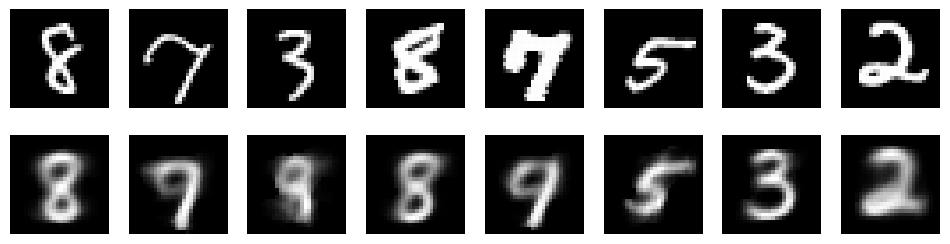

Training VAE...
Epoch 10, Loss: 159.7605
Epoch 20, Loss: 155.1892
Epoch 30, Loss: 152.9770
Epoch 40, Loss: 151.7156
Epoch 50, Loss: 150.7962


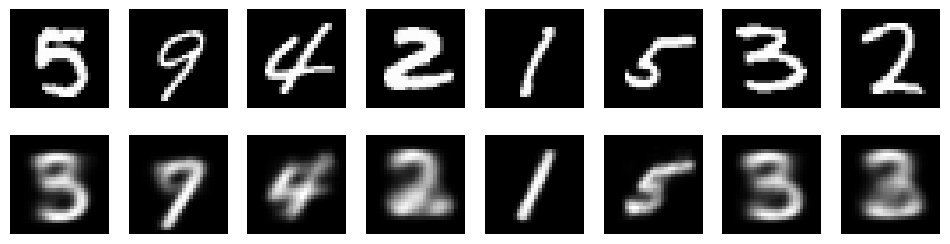

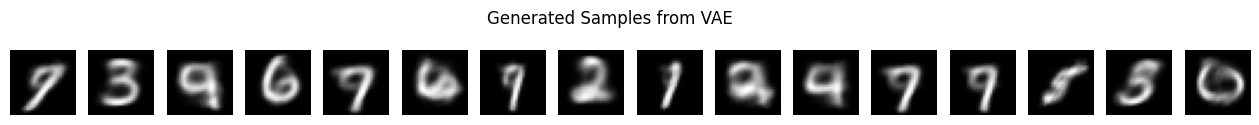

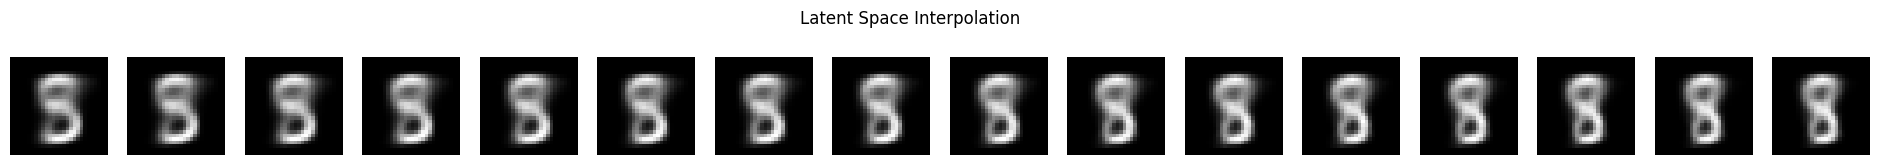

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# ----------------------
# Настройки
# ----------------------
device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size: int = 128
latent_dim: int = 2
epochs: int = 50

# ----------------------
# Датасет
# ----------------------
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# ----------------------
# Классический Autoencoder
# ----------------------
class AE(nn.Module):
    def __init__(self, latent_dim: int) -> None:
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 28*28),
            nn.Sigmoid()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

# ----------------------
# Variational Autoencoder
# ----------------------
class VAE(nn.Module):
    def __init__(self, latent_dim: int) -> None:
        super().__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        self.fc2 = nn.Linear(latent_dim, 128)
        self.fc3 = nn.Linear(128, 28*28)

    def encode(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        h = F.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        h = F.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar

# ----------------------
# Функции потерь
# ----------------------
def loss_ae(x_hat: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    return F.mse_loss(x_hat, x)

def loss_vae(x_hat: torch.Tensor, x: torch.Tensor, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
    bce = F.binary_cross_entropy(x_hat, x, reduction='sum')
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return bce + kld

# ----------------------
# Обучение модели
# ----------------------
def train(model: nn.Module, optimizer: torch.optim.Optimizer, is_vae: bool = False, epochs: int = epochs) -> None:
    model.train()
    for epoch in range(epochs):
        total_loss = 0.0
        for batch, _ in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            if is_vae:
                x_hat, mu, logvar = model(batch.view(batch.size(0), -1))
                loss = loss_vae(x_hat, batch.view(batch.size(0), -1), mu, logvar)
            else:
                x_hat = model(batch)
                loss = loss_ae(x_hat, batch.view(batch.size(0), -1))
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader.dataset):.4f}")

# ----------------------
# Визуализация реконструкций
# ----------------------
def plot_reconstructions(model: nn.Module, is_vae: bool = False, n: int = 8) -> None:
    model.eval()
    batch, _ = next(iter(train_loader))
    batch = batch.to(device)[:n]
    with torch.no_grad():
        if is_vae:
            x_hat, _, _ = model(batch.view(batch.size(0), -1))
        else:
            x_hat = model(batch)
    x_hat = x_hat.view(-1, 1, 28, 28).cpu()

    fig, axes = plt.subplots(2, n, figsize=(n*1.5, 3))
    for i in range(n):
        axes[0,i].imshow(batch[i].cpu().squeeze(), cmap='gray')
        axes[0,i].axis('off')
        axes[1,i].imshow(x_hat[i].squeeze(), cmap='gray')
        axes[1,i].axis('off')
    axes[0,0].set_ylabel('Original')
    axes[1,0].set_ylabel('Reconstructed')
    plt.show()

# ----------------------
# Генерация новых образцов VAE
# ----------------------
def generate_samples_vae(model: VAE, n: int = 16) -> None:
    model.eval()
    with torch.no_grad():
        z = torch.randn(n, latent_dim).to(device)
        samples = model.decode(z).view(-1, 1, 28, 28).cpu()

    fig, axes = plt.subplots(1, n, figsize=(n, 1.5))
    for i in range(n):
        axes[i].imshow(samples[i].squeeze(), cmap='gray')
        axes[i].axis('off')
    plt.suptitle('Generated Samples from VAE')
    plt.show()

# ----------------------
# Интерполяция в латентном пространстве VAE
# ----------------------
def interpolate_vae(model: VAE, n: int = 8) -> None:
    model.eval()
    batch, _ = next(iter(train_loader))
    batch = batch.to(device)[:2]
    with torch.no_grad():
        mu, logvar = model.encode(batch.view(2, -1))
        z1, z2 = mu[0], mu[1]
        alphas = torch.linspace(0, 1, n).unsqueeze(1).to(device)
        z_interp = z1 * (1 - alphas) + z2 * alphas
        samples = model.decode(z_interp).view(-1, 1, 28, 28).cpu()

    fig, axes = plt.subplots(1, n, figsize=(n*1.5, 2))
    for i in range(n):
        axes[i].imshow(samples[i].squeeze(), cmap='gray')
        axes[i].axis('off')
    plt.suptitle('Latent Space Interpolation')
    plt.show()

# ----------------------
# Обучение и визуализация AE
# ----------------------
print("Training AE...")
ae = AE(latent_dim).to(device)
optimizer_ae = torch.optim.Adam(ae.parameters(), lr=1e-3)
train(ae, optimizer_ae, is_vae=False)
plot_reconstructions(ae, is_vae=False)

# ----------------------
# Обучение и визуализация VAE
# ----------------------
print("Training VAE...")
vae = VAE(latent_dim).to(device)
optimizer_vae = torch.optim.Adam(vae.parameters(), lr=1e-3)
train(vae, optimizer_vae, is_vae=True)
plot_reconstructions(vae, is_vae=True)
generate_samples_vae(vae, n=16)
interpolate_vae(vae, n=16)

## 1.6 Conditional VAE (CVAE)
![cvae](assets/cvae.png)
### Идея

В обычном VAE:

- Мы обучаем модель реконструировать данные $x$ через латентную переменную $z$, **без учёта каких-либо меток**.  
- Латентное пространство упорядочивается априорно, но мы **не можем контролировать**, что именно генерирует декодер.

В CVAE мы хотим:

- Добавить **условие $y$**, которое управляет генерацией.  
- Например, $y$ — это класс изображения (цифра 0–9), атрибут лица или любой дополнительный сигнал.

---

### Модель CVAE

Мы расширяем обычный VAE:

**Prior (априорное распределение):**

$$
p(z \mid y) = \mathcal{N}(0, I)
$$

- Часто берут стандартное нормальное независимо от $y$.  
- Но можно сделать $p(z \mid y)$ специфическим для класса.

**Encoder (вариационное аппроксимация):**

$$
q_\phi(z \mid x, y) \approx p_\theta(z \mid x, y)
$$

- Теперь энкодер получает **и $x$, и $y$**.  
- Выдаёт параметры $\mu_\phi(x,y)$ и $\sigma_\phi(x,y)$.

**Decoder (likelihood):**

$$
p_\theta(x \mid z, y)
$$

- Декодер реконструирует $x$ с учётом условия $y$.  
- Латентное пространство всё ещё играет роль «шумовой» репрезентации.


### ELBO для CVAE

ELBO расширяется естественным образом:

$$
\mathcal{L}_{CVAE} = \mathbb{E}_{q_\phi(z \mid x, y)} \big[ \log p_\theta(x \mid z, y) \big] - KL\big(q_\phi(z \mid x, y) \,\|\, p(z \mid y)\big)
$$

- **Reconstruction term:** оцениваем лог-правдоподобие $x$ при фиксированном $z$ и $y$.  
- **KL term:** штрафуем отклонение латентного распределения от априорного для конкретного $y$.


### Reparameterization trick

Точно так же, как в обычном VAE:

$$
z = \mu_\phi(x, y) + \sigma_\phi(x, y) \odot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)
$$

- Позволяет **дифференцировать reconstruction term** по параметрам энкодера $\phi$.

### Интуиция

- Мы обучаемся на парах $(x, y)$, где $y$ — метка или условие.  
- Латентное пространство всё ещё содержит «шумовые» компоненты, которые позволяют генерации быть разнообразной.  
- CVAE позволяет генерировать новые $x$ с заданным $y$, например:  
  - цифру «3»  
  - лицо с конкретным атрибутом  
  - изображение с конкретной позой


### На практике

1. **Encoder:** получает concatenated input $(x, y)$ → выдаёт $(\mu, \sigma)$  
2. **Sampling:** с reparameterization → $z$  
3. **Decoder:** получает $(z, y)$ → генерирует $\hat{x}$  

**Loss:**

$$
\text{Loss} = \text{Reconstruction}(x, \hat{x}) + KL(q(z \mid x, y) \| p(z \mid y))
$$

- Reconstruction → MSE/BCE, в зависимости от типа данных  
- KL → аналитически

Epoch 5, Loss: 137.6910
Epoch 10, Loss: 134.4129
Epoch 15, Loss: 132.9475
Epoch 20, Loss: 132.0552
Epoch 25, Loss: 131.4638
Epoch 30, Loss: 130.9785


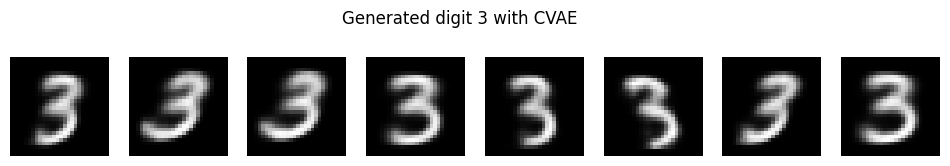

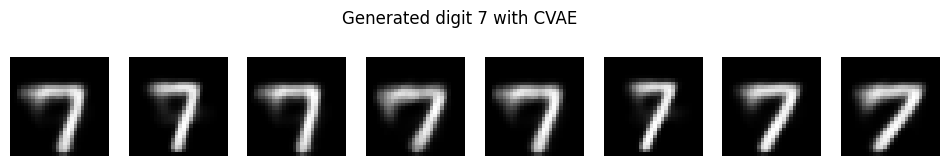

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# ----------------------
# Настройки
# ----------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 128
latent_dim = 2
epochs = 30
num_classes = 10  # MNIST: 0-9

# ----------------------
# Датасет
# ----------------------
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# ----------------------
# Conditional VAE
# ----------------------
class CVAE(nn.Module):
    def __init__(self, latent_dim: int, num_classes: int) -> None:
        super().__init__()
        self.latent_dim = latent_dim
        self.num_classes = num_classes
        input_dim = 28 * 28 + num_classes

        # Encoder
        self.fc1 = nn.Linear(input_dim, 256)
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

        # Decoder
        self.fc2 = nn.Linear(latent_dim + num_classes, 256)
        self.fc3 = nn.Linear(256, 28 * 28)

    def encode(self, x: torch.Tensor, y: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        x = torch.cat([x, y], dim=1)
        h = F.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        z = torch.cat([z, y], dim=1)
        h = F.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x: torch.Tensor, y: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        mu, logvar = self.encode(x, y)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z, y)
        return x_hat, mu, logvar

# ----------------------
# Loss function
# ----------------------
def loss_cvae(x_hat: torch.Tensor, x: torch.Tensor, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
    bce = F.binary_cross_entropy(x_hat, x, reduction='sum')
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return bce + kld

# ----------------------
# One-hot encoding
# ----------------------
def one_hot(labels: torch.Tensor, num_classes: int) -> torch.Tensor:
    return F.one_hot(labels, num_classes=num_classes).float()

# ----------------------
# Training function
# ----------------------
def train_cvae(model: nn.Module, train_loader: DataLoader, optimizer: torch.optim.Optimizer, device: torch.device, epochs: int = 30) -> None:
    model.train()
    for epoch in range(epochs):
        total_loss = 0.0
        for batch, labels in train_loader:
            batch = batch.view(batch.size(0), -1).to(device)
            y = one_hot(labels, model.num_classes).to(device)

            optimizer.zero_grad()
            x_hat, mu, logvar = model(batch, y)
            loss = loss_cvae(x_hat, batch, mu, logvar)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch + 1}, Loss: {total_loss / len(train_loader.dataset):.4f}")

# ----------------------
# Generation function
# ----------------------
def generate_cvae(model: nn.Module, digit: int, n: int, latent_dim: int, device: torch.device) -> None:
    model.eval()
    y = one_hot(torch.full((n,), digit, dtype=torch.long), model.num_classes).to(device)
    z = torch.randn(n, latent_dim).to(device)
    with torch.no_grad():
        samples = model.decode(z, y).view(-1, 1, 28, 28).cpu()

    fig, axes = plt.subplots(1, n, figsize=(n * 1.5, 2))
    for i in range(n):
        axes[i].imshow(samples[i].squeeze(), cmap='gray')
        axes[i].axis('off')
    plt.suptitle(f"Generated digit {digit} with CVAE")
    plt.show()

# ----------------------
# Запуск обучения и генерации
# ----------------------
cvae = CVAE(latent_dim, num_classes).to(device)
optimizer = torch.optim.Adam(cvae.parameters(), lr=1e-3)

train_cvae(cvae, train_loader, optimizer, device, epochs=epochs)

# Генерация примеров
generate_cvae(cvae, digit=3, n=8, latent_dim=latent_dim, device=device)
generate_cvae(cvae, digit=7, n=8, latent_dim=latent_dim, device=device)

# 2. VQ-VAE (Vector Quantized Variational Autoencoder)
## 2.1 Проблема стандартного VAE

- Стандартные VAE используют **непрерывное латентное пространство** $z \in \mathbb{R}^d$  
- При генерации часто получаем **размытые изображения**  
- Непрерывное $z$ плохо кодирует **дискретные структуры** (например, отдельные объекты, текстуры)  
- Интерполяция между точками $z$ может создавать «смазывание» между объектами  

**Вывод:** нужно дискретное, компактное и интерпретируемое латентное пространство.

---
## 2.2 Идея VQ-VAE: дискретизация латентного пространства
![vq_vae](assets/vq-vae.jpg)

1. Вводим **кодовую книгу (codebook)**:
   - **Codebook** — это **таблица дискретных векторов** (так называемых *embedding vectors*), которая хранит все возможные латентные коды. 
   $$\mathcal{E} = \{ e_1, e_2, \dots, e_K \}, \quad e_i \in \mathbb{R}^D$$
      - $K$ — количество дискретных кодов (размер codebook),
      - $D$ — размерность каждого кода (размер латентного вектора).
   - Эквивалентно: это как «словарь» или «таблица слов» в NLP, но для латентных векторов.
   - Каждый вектор — это прототип или представление некоторого класса паттернов данных.

2. Энкодер преобразует вход $x$ в **карту непрерывных векторов**:
$$Z_e(x) \in \mathbb{R}^{H \times W \times D}$$
   - $H \times W$ — количество позиций в пространственной сетке латентного представления
   - $D$ — размерность каждого латентного вектора
   - В каждой позиции $(i,j)$ находится D-мерный вектор: $z_e^{(i,j)}(x) \in \mathbb{R}^D$
   - Всего получаем $H \times W$ векторов

> **Важно:** Одно изображение кодируется в **сетку из $H \times W$ векторов**, а не в один вектор!

3. **Квантизация**: для **каждой позиции** $(i,j)$ выбираем ближайший код из codebook:
$$z_q^{(i,j)}(x) = e_{k_{i,j}}, \quad k_{i,j} = \arg\min_{\ell} \| z_e^{(i,j)}(x) - e_{\ell} \|_2$$
   - Получаем **карту квантованных векторов**: $Z_q(x) \in \mathbb{R}^{H \times W \times D}$
   - Эквивалентно: **карта индексов** $K(x) \in \{1,\dots,K\}^{H \times W}$

> **Интуитивно:**
> - Энкодер (обычно свёрточная сеть) уменьшает пространственные размеры изображения
> - На выходе энкодера: сетка $H \times W$ позиций, каждая позиция — вектор размерности $D$
> - Каждый вектор заменяется ближайшим из словаря
> - Изображение $\rightarrow$ сетка из $H \times W$ дискретных токенов (индексов в codebook)

4. Декодер генерирует реконструкцию $\hat{x}$ из $Z_q(x)$

**Схема:**

```
x [3×256×256] → Encoder → Z_e(x) [H×W×D] → Quantize → Z_q(x) [H×W×D] → Decoder → x̂ [3×256×256]
↓
Сетка H×W векторов k₁₁, k₁₂, ..., k_{HW} (индексы из codebook)
каждый вектор ∈ ℝ^D

```

**Пример:**
- Входное изображение: $3 \times 256 \times 256$
- После энкодера: $32 \times 32 \times 256$ 
  - Сетка $32 \times 32 = 1024$ позиций
  - Каждая позиция содержит вектор размерности $D = 256$
- Квантизация: каждый из 1024 векторов заменяется ближайшим из $K$ кодов (например, $K = 512$)
- Результат: сетка $32 \times 32$ индексов из $\{1, \ldots, 512\}$
- Декодер восстанавливает изображение из квантованной карты

---

## 2.3 Функция потерь VQ-VAE

$$\mathcal{L}_{\text{VQ-VAE}} = L_{\text{rec}} + L_{\text{codebook}} + L_{\text{commit}}$$

### Reconstruction loss
$$L_{\text{rec}} = \| x - \hat{x} \|^2$$
- Стандартная MSE между входом и выходом декодера  
- Аналог **первого члена ELBO в VAE** (likelihood term)

### Codebook loss
$$L_{\text{codebook}} = \sum_{i,j} \| \text{sg}[z_e^{(i,j)}(x)] - e_{k_{i,j}} \|^2$$
- **Обновляет кодовую книгу** $\mathcal{E}$, притягивая выбранные коды к выходам энкодера
- Суммируется **по всем позициям** $(i,j)$ латентной карты
- **Stop-gradient** $\text{sg}[\cdot]$ → градиент не идёт в энкодер, только в векторы codebook

### Commitment loss
$$L_{\text{commit}} = \beta \sum_{i,j} \| z_e^{(i,j)}(x) - \text{sg}[e_{k_{i,j}}] \|^2$$
- **Заставляет энкодер приближать свои выходы к выбранным кодам**
- Суммируется **по всем позициям** $(i,j)$ латентной карты
- $\beta$ — гиперпараметр (обычно ~0.25–0.5)  
- **Stop-gradient** → градиенты не проходят в codebook  

### Механизм работы потерь
- **Для каждой позиции** $(i,j)$ в латентной карте:
  - Codebook loss: двигает $e_{k_{i,j}}$ ближе к $z_e^{(i,j)}$
  - Commitment loss: двигает $z_e^{(i,j)}$ ближе к $e_{k_{i,j}}$
- Stop-gradient предотвращает конфликт между обновлениями
- Reconstruction loss обучает энкодер и декодер через стандартный backpropagation

### Straight-Through Estimator
- Проблема: квантизация (выбор ближайшего $e_k$) **недифференцируема**
- Решение: при обратном проходе градиент от декодера копируется напрямую к энкодеру:
$$\frac{\partial L}{\partial z_e^{(i,j)}} = \frac{\partial L}{\partial z_q^{(i,j)}}$$
- Это позволяет обучать энкодер, несмотря на дискретную операцию квантизации

## 2.4 Связь с ELBO

- В стандартном VAE: 
$$\text{ELBO} = \mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)] - D_{KL}(q_\phi(z|x)\|p(z))$$

- В VQ-VAE:
  - **Дискретная переменная** $z_q(x)$ заменяет непрерывное $z$  
  - **Reconstruction loss** → аналог likelihood term $\mathbb{E}_{q(z|x)}[\log p_\theta(x|z)]$
  - **Codebook + commitment loss** → неявная регуляризация латентного пространства (аналог роли KL-term)
  - Вместо явного prior $p(z)$ используется дискретное множество векторов $\mathcal{E}$

$$\log p_\theta(x) \approx \mathbb{E}_{z_q \sim q(z_q|x)}[\log p_\theta(x|z_q)]$$

- Stop-gradient механизмы позволяют реализовать **эффективное обучение дискретного латентного пространства**, хотя явная KL-дивергенция не вычисляется.

---

## 2.5 Преимущества VQ-VAE и применение

**Преимущества:**
- Дискретное латентное пространство → **чёткие изображения**  
- Кодовая книга → **эффективное представление дискретных структур и паттернов**  
- Commitment loss → стабилизирует обучение энкодера  
- Легко интегрировать с **autoregressive моделями** (PixelCNN, Transformer)  

**Применение:**
- **DALL·E**:
  - VQ-VAE кодирует изображения в последовательность дискретных токенов  
  - Transformer обучается моделировать совместное распределение текстовых и визуальных токенов
  - Результат: **высококачественные изображения с чёткими границами и текстурами**  
  
- VQ-VAE также применяется для:
  - компрессии изображений и видео
  - генерации и синтеза речи (VQ-VAE-2, Jukebox)
  - дискретного представления сложных данных  

Epoch 1, Loss: 0.0007
Epoch 6, Loss: 0.0004
Epoch 11, Loss: 0.0004
Epoch 16, Loss: 0.0004
Epoch 21, Loss: 0.0004
Epoch 26, Loss: 0.0004
Epoch 31, Loss: 0.0004
Epoch 36, Loss: 0.0004
Epoch 41, Loss: 0.0004
Epoch 46, Loss: 0.0004


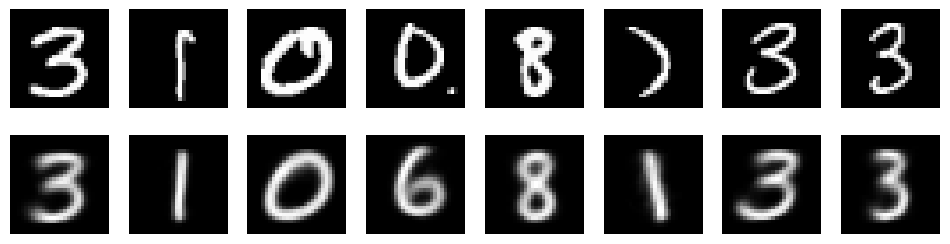

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt


# ----------------------
# Vector Quantizer
# ----------------------
class VectorQuantizer(nn.Module):
    def __init__(self, num_embeddings: int, embedding_dim: int, beta: float = 0.25) -> None:
        super().__init__()
        self.embedding_dim = embedding_dim
        self.num_embeddings = num_embeddings
        self.beta = beta

        self.embedding = nn.Embedding(num_embeddings, embedding_dim)
        self.embedding.weight.data.uniform_(-1 / num_embeddings, 1 / num_embeddings)

    def forward(self, z: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """
        z: (B, latent_dim)
        Returns:
            z_q: quantized tensor
            vq_loss: VQ loss
        """
        z_flattened = z.view(-1, self.embedding_dim)
        distances = (
            (z_flattened**2).sum(dim=1, keepdim=True)
            + (self.embedding.weight**2).sum(dim=1)
            - 2 * z_flattened @ self.embedding.weight.t()
        )
        encoding_indices = torch.argmin(distances, dim=1)
        z_q = self.embedding(encoding_indices).view(z.shape)

        # VQ loss
        vq_loss = F.mse_loss(z_q.detach(), z) + self.beta * F.mse_loss(z_q, z.detach())
        # straight-through estimator
        z_q = z + (z_q - z).detach()
        return z_q, vq_loss


# ----------------------
# VQ-VAE Model
# ----------------------
class VQVAE(nn.Module):
    def __init__(self, latent_dim: int, num_embeddings: int) -> None:
        super().__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim),
        )
        self.vq = VectorQuantizer(num_embeddings, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 28 * 28),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        z_e = self.encoder(x)
        z_q, vq_loss = self.vq(z_e)
        x_hat = self.decoder(z_q)
        return x_hat, vq_loss


# ----------------------
# Loss Function
# ----------------------
def loss_vqvae(x_hat: torch.Tensor, x: torch.Tensor, vq_loss: torch.Tensor) -> torch.Tensor:
    x_flat = x.view(x.size(0), -1)
    recon_loss = F.mse_loss(x_hat, x_flat)
    return recon_loss + vq_loss


# ----------------------
# Training Function
# ----------------------
def train_vqvae(
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    train_loader: DataLoader,
    epochs: int = 20,
    device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu"),
) -> None:
    model.train()
    for epoch in range(epochs):
        total_loss = 0.0
        for batch, _ in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            x_hat, vq_loss = model(batch)
            loss = loss_vqvae(x_hat, batch, vq_loss)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if epoch % 5 == 0:
            print(f"Epoch {epoch + 1}, Loss: {total_loss / len(train_loader.dataset):.4f}")


# ----------------------
# Visualization
# ----------------------
def plot_reconstructions(model: nn.Module, train_loader: DataLoader, n: int = 8, device: torch.device = None) -> None:
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.eval()
    batch, _ = next(iter(train_loader))
    batch = batch.to(device)[:n]

    with torch.no_grad():
        x_hat, _ = model(batch)

    x_hat = x_hat.view(-1, 1, 28, 28).cpu()

    fig, axes = plt.subplots(2, n, figsize=(n * 1.5, 3))
    for i in range(n):
        axes[0, i].imshow(batch[i].cpu().squeeze(), cmap="gray")
        axes[0, i].axis("off")
        axes[1, i].imshow(x_hat[i].squeeze(), cmap="gray")
        axes[1, i].axis("off")
    axes[0, 0].set_ylabel("Original")
    axes[1, 0].set_ylabel("Reconstructed")
    plt.show()


latent_dim: int = 64
num_embeddings: int = 512
batch_size: int = 128
epochs: int = 50
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

model = VQVAE(latent_dim, num_embeddings).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_vqvae(model, optimizer, train_loader, epochs=epochs, device=device)
plot_reconstructions(model, train_loader, n=8, device=device)
